# Analisis y Procesamiento de señales

## Facundo Ivan CARRANZA, TS7 Transformada Z y respuesta en frecuencia

### Introduccion teorica

#### La transformada Z es una herramienta fundamental para analizar y diseñar sistemas digitales. Permite representar señales y sistemas discretos en un dominio complejo donde resulta más sencillo estudiar su comportamiento, de forma similar a como la transformada de Laplace se utiliza en sistemas continuos.

#### Su principal ventaja es que convierte retardos y sumas en expresiones algebraicas, facilitando el análisis de estabilidad, causalidad y respuesta del sistema. Estos aspectos se determinan observando la posición de polos y ceros en el plano Z, cuya ubicación define si un sistema es estable y cómo modifica la señal que lo atraviesa.

#### La respuesta en frecuencia se obtiene evaluando la transformada Z sobre el círculo unitario, lo que permite ver cómo el sistema afecta la amplitud y la fase de cada componente de frecuencia. Así, la transformada Z se convierte en un puente entre el dominio temporal y el análisis frecuencial, siendo clave en el procesamiento digital de señales y en el diseño de filtros digitales.

## Analisis desarrollo y discusion

#### Para analizar la transformada Z y su respuesta en frecuencia
 
#### 1) se buscara hallar la funcion transferencia

#### 2)Se buscara calcular la respuesta en frecuencia de modulo y fase
 
#### 3) Simular y validar la respuesta en frecuencia de todos los sistemas con numpy.

#### Para el punto 1 y 2 se realizo a mano los ejercicios a mano obteniendo lo siguiente:

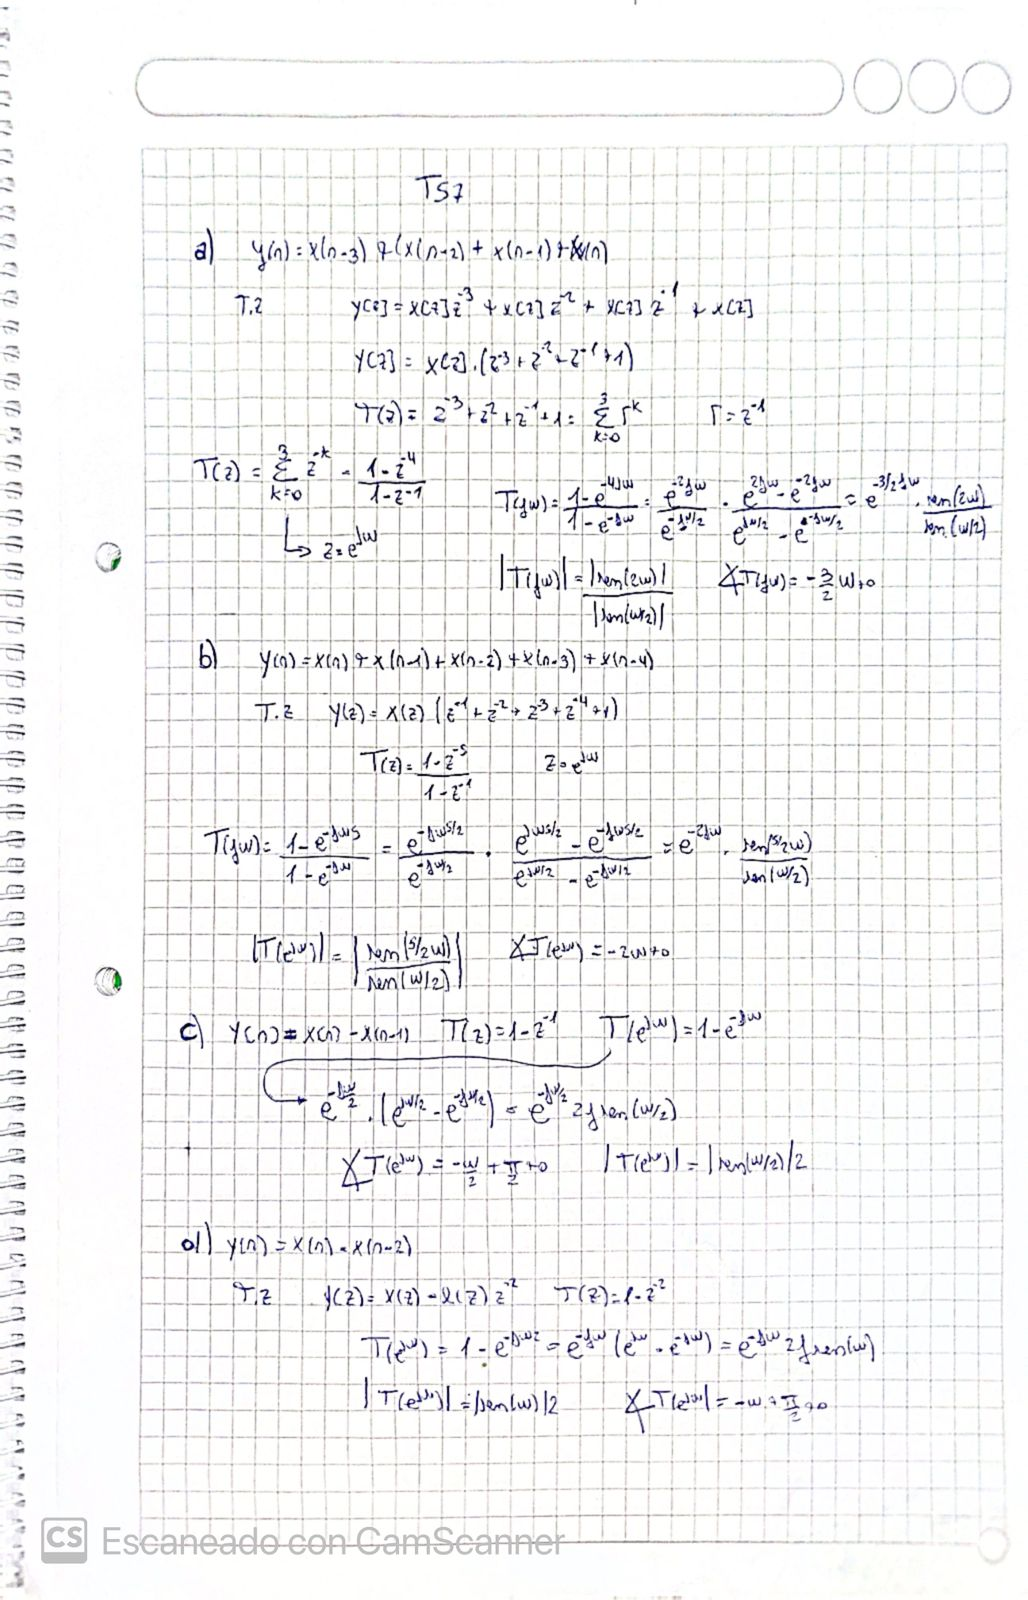

#### Para poder comprar los resultados con los obtenidos mas adelante con los obtenidos con spyder, se grafico los resultados de modulo y fase para cada uno de los puntos obteniendo lo siguiente

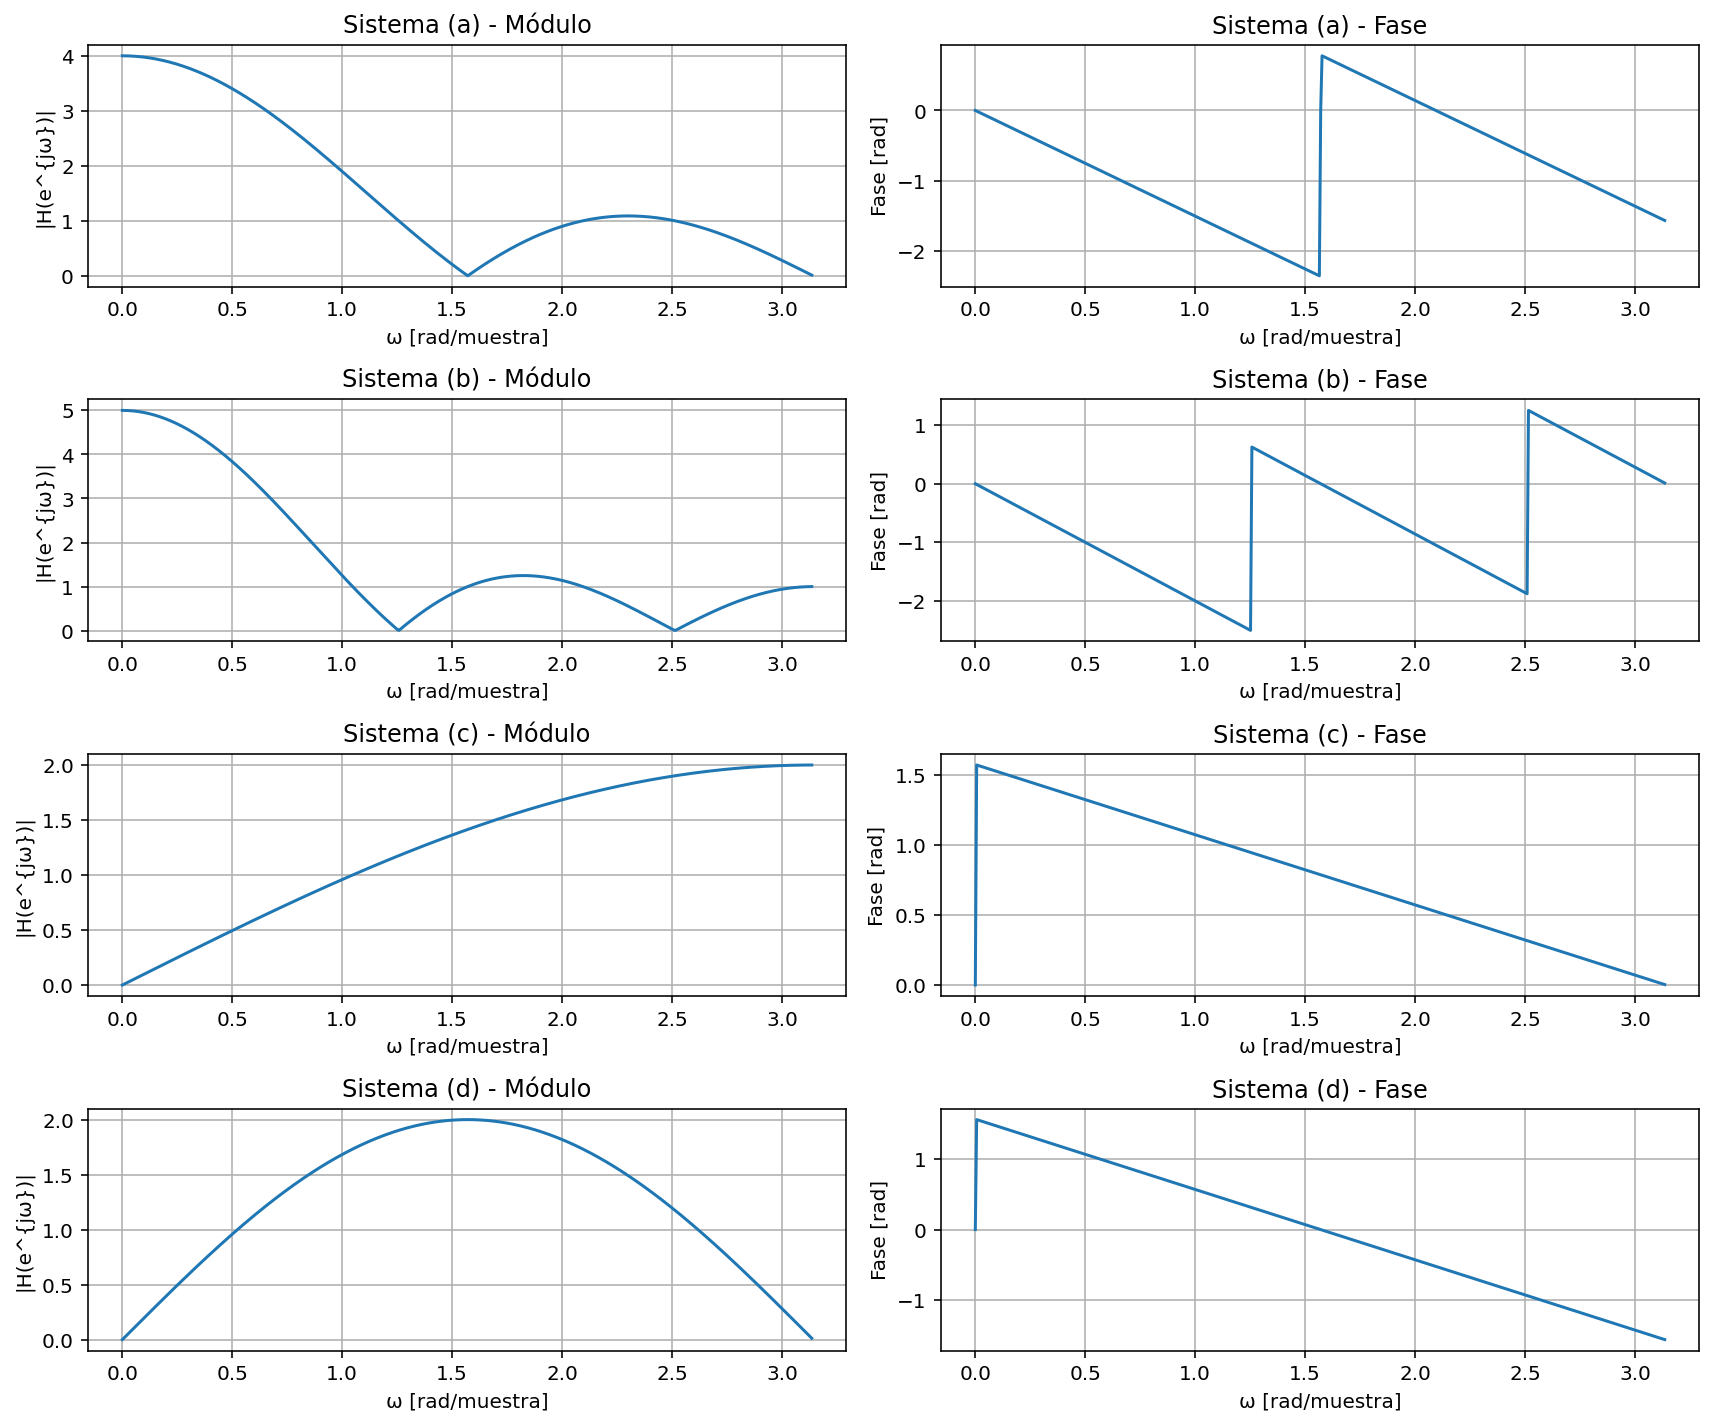

#### Las respuestas en frecuencia obtenidas muestran claramente el comportamiento de los cuatro sistemas analizados. Los sistemas (a) y (b), correspondientes a medias móviles de 4 y 5 puntos, presentan un módulo máximo en bajas frecuencias y una marcada atenuación en las altas, lo que confirma su naturaleza de filtros pasabajos FIR. En contraste, los sistemas (c) y (d), basados en diferencias entre muestras, exhiben módulo nulo en bajas frecuencias y un crecimiento hacia la zona media o alta del espectro, comportándose como filtros pasaaltos o diferenciadores. Las fases de todos los sistemas son lineales, con los saltos esperables en los filtros FIR de media móvil. En conjunto, las gráficas validan que cada ecuación en diferencias produce el tipo de filtro teórico esperado.

#### Finalmente, se fijó una frecuencia de muestreo arbitraria de fs=1000 Hz, con el propósito de expresar los resultados directamente en unidades de frecuencia (Hz) en lugar de radianes por muestra (rad/muestra), evitando así la necesidad de un reescalado posterior. Para utilizar el codigo se definieron los siguientes vectores y cte

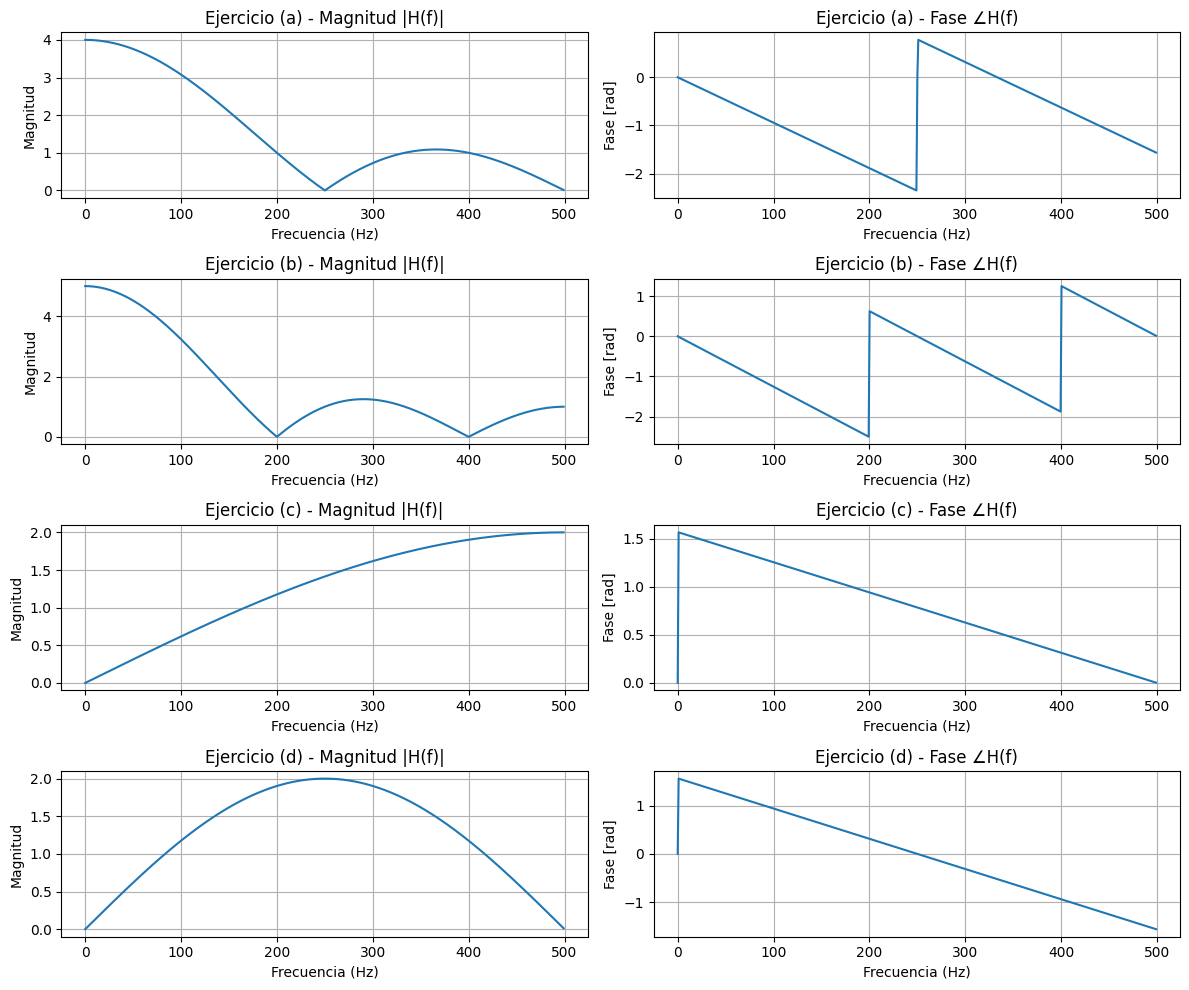

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# ==========================
# 1. Coeficientes de cada sistema
# ==========================
ba = [1,1,1,1]        # sistema (a)
bb = [1,1,1,1,1]      # sistema (b)
bc = [1,-1]           # sistema (c)
bd = [1,0,-1]         # sistema (d) -> CORRECTO

# Frecuencia de muestreo (Hz)
fs = 1000  

# ==========================
# 2. Respuesta en frecuencia (en Hz)
# ==========================
wa, ha = sig.freqz(b=ba, a=1, fs=fs)
wb, hb = sig.freqz(b=bb, a=1, fs=fs)
wc, hc = sig.freqz(b=bc, a=1, fs=fs)
wd, hd = sig.freqz(b=bd, a=1, fs=fs)

# Magnitud y fase
maga, fasea = np.abs(ha), np.unwrap(np.angle(ha))
magb, faseb = np.abs(hb), np.unwrap(np.angle(hb))
magc, fasec = np.abs(hc), np.unwrap(np.angle(hc))
magd, fased = np.abs(hd), np.unwrap(np.angle(hd))

# ==========================
# 3. Gráficos prolijos y ordenados
# ==========================

labels = ['Ejercicio (a)', 'Ejercicio (b)', 'Ejercicio (c)', 'Ejercicio (d)']
w_list = [wa, wb, wc, wd]
mag_list = [maga, magb, magc, magd]
fase_list = [fasea, faseb, fasec, fased]

plt.figure(figsize=(12,10))

for i in range(4):
    
    # Magnitud
    plt.subplot(4,2,2*i+1)
    plt.plot(w_list[i], mag_list[i])
    plt.title(f'{labels[i]} - Magnitud |H(f)|')
    plt.ylabel('Magnitud')
    plt.xlabel('Frecuencia (Hz)')
    plt.grid(True)

    # Fase
    plt.subplot(4,2,2*i+2)
    plt.plot(w_list[i], fase_list[i])
    plt.title(f'{labels[i]} - Fase ∠H(f)')
    plt.ylabel('Fase [rad]')
    plt.xlabel('Frecuencia (Hz)')
    plt.grid(True)

plt.tight_layout()
plt.show()

#### Los dos conjuntos de gráficos representan los mismos cuatro filtros, pero en dominios de frecuencia distintos. El primero muestra la respuesta en frecuencia en términos de la frecuencia normalizada ω (radianes por muestra), tal como se plantea en el desarrollo teórico. El segundo gráfico expresa exactamente la misma información, pero convertida a Hz usando una frecuencia de muestreo de 1000 Hz. Por eso la forma de cada curva —sus máximos, mínimos, ceros y la tendencia de la fase— es idéntica en ambos casos; solo cambia la escala del eje horizontal. En radianes la frecuencia llega hasta π, mientras que en Hz llega hasta 500 Hz (Nyquist). En resumen, ambos gráficos validan lo mismo: los sistemas (a) y (b) se comportan como pasabajos, mientras que (c) y (d) actúan como diferenciadores; la diferencia está únicamente en cómo se representa la frecuencia.

## Conclusiones

#### El análisis realizado permitió caracterizar completamente el comportamiento de los cuatro sistemas discretos propuestos a partir de sus ecuaciones en diferencias. Mediante la transformada Z se obtuvieron sus funciones de transferencia, lo que permitió identificar polos, ceros y el tipo de filtro que representan. Posteriormente, la evaluación sobre el círculo unitario y la simulación numérica confirmaron que los sistemas (a) y (b) corresponden a filtros pasabajos de tipo media móvil, mientras que los sistemas (c) y (d) actúan como diferenciadores, resaltando componentes de alta frecuencia. La comparación entre los resultados teóricos y los obtenidos mediante freqz mostró una coincidencia total, validando tanto el desarrollo matemático como la implementación digital. En conjunto, el trabajo permitió integrar teoría y práctica para comprender cómo una ecuación en diferencias define completamente la respuesta en frecuencia de un sistema discreto

## Autoaprendizaje

#### Al realizar este trabajo comprendí cómo una ecuación en diferencias puede describir por completo el comportamiento de un sistema digital y cómo interpretar dicha información mediante la transformada Z. Aprendí a obtener la función de transferencia, analizar sus polos y ceros, y relacionar su forma con el tipo de filtro que representa. También entendí la conexión entre la teoría y la práctica: cómo la respuesta en frecuencia teórica en radianes coincide perfectamente con la simulación en Hz al elegir una frecuencia de muestreo. Además, familiarizarme con herramientas como freqz, la magnitud, fase y la visualización de los resultados me permitió reforzar conceptos importantes de procesamiento digital de señales. En resumen, el trabajo me ayudó a integrar la teoría matemática con la implementación práctica y a interpretar correctamente el comportamiento de distintos filtros FIR sencillos.